# Thyroid Cancer Prediction using ANN with scikit-learn

## Read Dataset "thyroid_cancer_risk_data.csv"

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv("thyroid_cancer_risk_data.csv")

In [5]:
print(df.shape)
print(df.head())

(212691, 17)
   Patient_ID  Age  Gender  Country  Ethnicity Family_History  \
0           1   66    Male   Russia  Caucasian             No   
1           2   29    Male  Germany   Hispanic             No   
2           3   86    Male  Nigeria  Caucasian             No   
3           4   75  Female    India      Asian             No   
4           5   35  Female  Germany    African            Yes   

  Radiation_Exposure Iodine_Deficiency Smoking Obesity Diabetes  TSH_Level  \
0                Yes                No      No      No       No       9.37   
1                Yes                No      No      No       No       1.83   
2                 No                No      No      No       No       6.26   
3                 No                No      No      No       No       4.10   
4                Yes                No      No      No       No       9.10   

   T3_Level  T4_Level  Nodule_Size Thyroid_Cancer_Risk Diagnosis  
0      1.67      6.16         1.08                 Low    Be

## Feature Matrix and Label Vector

In [7]:
feature_cols = df.columns.tolist()
feature_cols.remove("Patient_ID")
feature_cols.remove('Diagnosis')
X = df[feature_cols]

y = df['Diagnosis']


In [8]:
X

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk
0,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low
1,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low
2,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low
3,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium
4,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,58,Female,India,Asian,No,No,No,No,Yes,No,2.00,0.64,11.92,1.48,Low
212687,89,Male,Japan,Middle Eastern,No,No,No,No,Yes,No,9.77,3.25,7.30,4.46,Medium
212688,72,Female,Nigeria,Hispanic,No,No,No,No,No,Yes,7.72,2.44,8.71,2.36,Medium
212689,85,Female,Brazil,Middle Eastern,No,No,No,No,No,Yes,5.62,2.53,9.62,1.54,Medium


In [9]:
y

0            Benign
1            Benign
2            Benign
3            Benign
4            Benign
            ...    
212686       Benign
212687       Benign
212688       Benign
212689       Benign
212690    Malignant
Name: Diagnosis, Length: 212691, dtype: object

## Data Cleaning

In [11]:
yes_no_cols = ["Family_History", "Radiation_Exposure", "Iodine_Deficiency", 
               "Smoking", "Obesity", "Diabetes"]

X.loc[:, yes_no_cols] = X[yes_no_cols].replace({'Yes': 1, 'No': 0})

/var/folders/3w/p67dkhvd2_x822z48p6czcj40000gn/T/ipykernel_20329/1138043904.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.loc[:, yes_no_cols] = X[yes_no_cols].replace({'Yes': 1, 'No': 0})


### One Hot Encoder

In [13]:
from sklearn.preprocessing import OneHotEncoder   
temp = ["Gender","Country","Ethnicity","Thyroid_Cancer_Risk"]
X_cat = pd.get_dummies(df[temp])
X_new = pd.concat([X,X_cat], axis=1).drop(columns = temp)
X_new

,Age,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,...,Country_UK,Country_USA,Ethnicity_African,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic,Ethnicity_Middle Eastern,Thyroid_Cancer_Risk_High,Thyroid_Cancer_Risk_Low,Thyroid_Cancer_Risk_Medium
0,66,0,1,0,0,0,0,9.37,1.67,6.16,...,False,False,False,False,True,False,False,False,True,False
1,29,0,1,0,0,0,0,1.83,1.73,10.54,...,False,False,False,False,False,True,False,False,True,False
2,86,0,0,0,0,0,0,6.26,2.59,10.57,...,False,False,False,False,True,False,False,False,True,False
3,75,0,0,0,0,0,0,4.10,2.62,11.04,...,False,False,False,True,False,False,False,False,False,True
4,35,1,1,0,0,0,0,9.10,2.11,10.71,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,58,0,0,0,0,1,0,2.00,0.64,11.92,...,False,False,False,True,False,False,False,False,True,False
212687,89,0,0,0,0,1,0,9.77,3.25,7.30,...,False,False,False,False,False,False,True,False,False,True
212688,72,0,0,0,0,0,1,7.72,2.44,8.71,...,False,False,False,False,False,True,False,False,False,True
212689,85,0,0,0,0,0,1,5.62,2.53,9.62,...,False,False,False,False,False,False,True,False,False,True


In [14]:
X_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Age                         212691 non-null  int64  
 1   Family_History              212691 non-null  object 
 2   Radiation_Exposure          212691 non-null  object 
 3   Iodine_Deficiency           212691 non-null  object 
 4   Smoking                     212691 non-null  object 
 5   Obesity                     212691 non-null  object 
 6   Diabetes                    212691 non-null  object 
 7   TSH_Level                   212691 non-null  float64
 8   T3_Level                    212691 non-null  float64
 9   T4_Level                    212691 non-null  float64
 10  Nodule_Size                 212691 non-null  float64
 11  Gender_Female               212691 non-null  bool   
 12  Gender_Male                 212691 non-null  bool   
 13  Country_Brazil

In [15]:
y_new = y.map({'Benign': 0, 'Malignant': 1})
y_new

0         0
1         0
2         0
3         0
4         0
         ..
212686    0
212687    0
212688    0
212689    0
212690    1
Name: Diagnosis, Length: 212691, dtype: int64

## Splitting Dataset 20% & ANN Classifier 


### ANN Classifier 1

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=2)

In [61]:
from sklearn.neural_network import MLPClassifier

my_ANN1 = MLPClassifier(hidden_layer_sizes=(20,10), activation= 'logistic', 
                       solver='adam', alpha=1e-5, random_state=1, 
                       learning_rate_init = 0.001, verbose=True, max_iter = 500, tol=0.0001)

#### Train

In [64]:
my_ANN1.fit(X_train, y_train)

Iteration 1, loss = 0.54626300
Iteration 2, loss = 0.45527482
Iteration 3, loss = 0.45221389
Iteration 4, loss = 0.45196542
Iteration 5, loss = 0.45176851
Iteration 6, loss = 0.45170471
Iteration 7, loss = 0.45166951
Iteration 8, loss = 0.45161632
Iteration 9, loss = 0.45160598
Iteration 10, loss = 0.45161323
Iteration 11, loss = 0.45154322
Iteration 12, loss = 0.45152474
Iteration 13, loss = 0.45152821
Iteration 14, loss = 0.45151209
Iteration 15, loss = 0.45148551
Iteration 16, loss = 0.45153835
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


MLPClassifier(activation='logistic', alpha=1e-05, hidden_layer_sizes=(20, 10),
              max_iter=500, random_state=1, verbose=True)

In [66]:
from sklearn.metrics import accuracy_score

y_pred1 = my_ANN1.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred1))

Test Accuracy: 0.8274524553938739


### ANN Classifier 2

In [24]:
my_ANN2 = MLPClassifier(hidden_layer_sizes=(20,10,20), activation= 'relu', 
                       solver='adam', alpha=1e-5, random_state=1, 
                       learning_rate_init = 0.000001, verbose=True,max_iter = 1000, tol=0.0000001)
my_ANN2.fit(X_train, y_train)

Iteration 1, loss = 0.59175662
Iteration 2, loss = 0.58257872
Iteration 3, loss = 0.57534347
Iteration 4, loss = 0.56962180
Iteration 5, loss = 0.56511165
Iteration 6, loss = 0.56159253
Iteration 7, loss = 0.55887744
Iteration 8, loss = 0.55676496
Iteration 9, loss = 0.55506806
Iteration 10, loss = 0.55364512
Iteration 11, loss = 0.55238614
Iteration 12, loss = 0.55123987
Iteration 13, loss = 0.55018775
Iteration 14, loss = 0.54921611
Iteration 15, loss = 0.54831993
Iteration 16, loss = 0.54749433
Iteration 17, loss = 0.54673400
Iteration 18, loss = 0.54603023
Iteration 19, loss = 0.54537749
Iteration 20, loss = 0.54478503
Iteration 21, loss = 0.54423987
Iteration 22, loss = 0.54374561
Iteration 23, loss = 0.54330330
Iteration 24, loss = 0.54289673
Iteration 25, loss = 0.54252220
Iteration 26, loss = 0.54217247
Iteration 27, loss = 0.54184856
Iteration 28, loss = 0.54154989
Iteration 29, loss = 0.54126881
Iteration 30, loss = 0.54100187
Iteration 31, loss = 0.54074966
Iteration 32, los

/Users/joseescobar/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(alpha=1e-05, hidden_layer_sizes=(20, 10, 20),
              learning_rate_init=1e-06, max_iter=1000, random_state=1,
              tol=1e-07, verbose=True)

In [25]:
y_pred2 = my_ANN2.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred2))

Test Accuracy: 0.8275229789134676


### ANN Clasifier 3

In [27]:
my_ANN3 = MLPClassifier(hidden_layer_sizes=(50,30,20,10), activation= 'relu', 
                       solver='adam', alpha=1e-4, random_state=1, 
                       learning_rate_init = 0.0001, verbose=True,max_iter = 2000, tol=0.0000001)
my_ANN3.fit(X_train, y_train)

Iteration 1, loss = 0.54485555
Iteration 2, loss = 0.47042628
Iteration 3, loss = 0.45744116
Iteration 4, loss = 0.45507869
Iteration 5, loss = 0.45349297
Iteration 6, loss = 0.45305733
Iteration 7, loss = 0.45303208
Iteration 8, loss = 0.45284571
Iteration 9, loss = 0.45292305
Iteration 10, loss = 0.45278794
Iteration 11, loss = 0.45246423
Iteration 12, loss = 0.45252710
Iteration 13, loss = 0.45252558
Iteration 14, loss = 0.45256809
Iteration 15, loss = 0.45253126
Iteration 16, loss = 0.45242301
Iteration 17, loss = 0.45235725
Iteration 18, loss = 0.45222696
Iteration 19, loss = 0.45223766
Iteration 20, loss = 0.45229600
Iteration 21, loss = 0.45231636
Iteration 22, loss = 0.45211536
Iteration 23, loss = 0.45223707
Iteration 24, loss = 0.45216789
Iteration 25, loss = 0.45227387
Iteration 26, loss = 0.45213756
Iteration 27, loss = 0.45199860
Iteration 28, loss = 0.45212671
Iteration 29, loss = 0.45186141
Iteration 30, loss = 0.45190473
Iteration 31, loss = 0.45195498
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(50, 30, 20, 10), learning_rate_init=0.0001,
              max_iter=2000, random_state=1, tol=1e-07, verbose=True)

In [28]:
y_pred3 = my_ANN3.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred3))

Test Accuracy: 0.8274524553938739


In [29]:
y_predict_ann = my_ANN3.predict(X_test)
print("Test Accuracy ANN3:", accuracy_score(y_test, y_pred2))


Test Accuracy ANN3: 0.8275229789134676


## TPR, FPR ,AUC & ROC Curve

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = my_ANN3.predict_proba(X_test)[:, 1]  # Probabilities for Malignant (class 1)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 0.6981750339116818


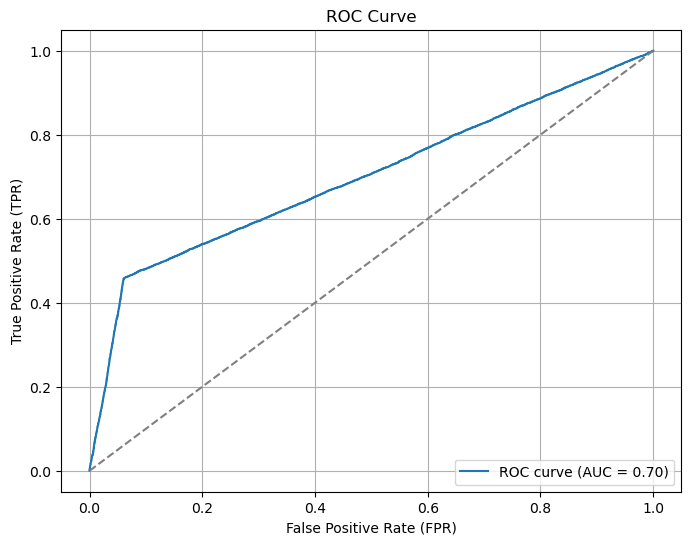

In [31]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line for random guess
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Cross- Validation 10-Fold

In [32]:
from sklearn.model_selection import cross_val_score

my_ANN4 = MLPClassifier(hidden_layer_sizes=(10,20,10), activation= 'relu', 
                       solver='adam', alpha=1e-4, random_state=1, 
                       learning_rate_init = 0.001, verbose=True, tol=0.00001)

accuracy_list = cross_val_score(my_ANN4, X_new, y_new, cv=10, scoring='accuracy')

print('\n\n','accuracy: ',accuracy_list)

accuracy_cv = accuracy_list.mean()

print(accuracy_cv)

Iteration 1, loss = 0.50488720
Iteration 2, loss = 0.45307500
Iteration 3, loss = 0.45193197
Iteration 4, loss = 0.45165066
Iteration 5, loss = 0.45155270
Iteration 6, loss = 0.45150456
Iteration 7, loss = 0.45143051
Iteration 8, loss = 0.45141211
Iteration 9, loss = 0.45132332
Iteration 10, loss = 0.45136124
Iteration 11, loss = 0.45131359
Iteration 12, loss = 0.45131874
Iteration 13, loss = 0.45123120
Iteration 14, loss = 0.45137344
Iteration 15, loss = 0.45135672
Iteration 16, loss = 0.45130581
Iteration 17, loss = 0.45119963
Iteration 18, loss = 0.45124583
Iteration 19, loss = 0.45130338
Iteration 20, loss = 0.45129422
Iteration 21, loss = 0.45125886
Iteration 22, loss = 0.45120962
Iteration 23, loss = 0.45123759
Iteration 24, loss = 0.45121683
Iteration 25, loss = 0.45121926
Iteration 26, loss = 0.45117598
Iteration 27, loss = 0.45124072
Iteration 28, loss = 0.45119994
Iteration 29, loss = 0.45118405
Iteration 30, loss = 0.45122419
Iteration 31, loss = 0.45118447
Iteration 32, los

In [56]:
accuracy_cv = accuracy_list.mean()

print(accuracy_cv)

0.8272893563481711
